# Testing Notebook 
This notebook is to test our class and functions 

## Imports

In [1]:
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random, importlib
import matplotlib.pyplot as plt
from typing import List

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
import random
import cv2
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer, ColorMode

# import our functions 
os.chdir("../preprocessing")
import tumor_dataset

importlib.reload(tumor_dataset)
from tumor_dataset import Dataset

In [2]:
d = Dataset(data_path="../../data/raw_data/useable_data")
# d.preprocess_images(read_bins=False)
#d.split_train_val_test(75, 10, 15)
#d.cashe_data()
d.register_instances(rgb=True)

Init Dataset


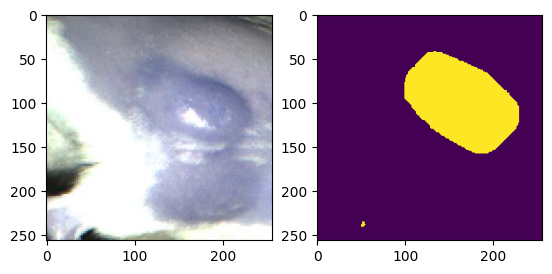

In [4]:
images, masks = d.return_data()
fig, ax = plt.subplots(1,2)
ax[0].imshow(images[12])
ax[1].imshow(masks[12])

In [4]:
d.convert_binary_to_coco()

Created 181 annotations for images in folder: /home/am0532/tumor-seg/data/processed_data/rgb/train/masks
Created 24 annotations for images in folder: /home/am0532/tumor-seg/data/processed_data/rgb/val/masks
Created 36 annotations for images in folder: /home/am0532/tumor-seg/data/processed_data/rgb/test/masks
Created 181 annotations for images in folder: /home/am0532/tumor-seg/data/processed_data/depth/train/masks
Created 24 annotations for images in folder: /home/am0532/tumor-seg/data/processed_data/depth/val/masks
Created 36 annotations for images in folder: /home/am0532/tumor-seg/data/processed_data/depth/test/masks
Created 181 annotations for images in folder: /home/am0532/tumor-seg/data/processed_data/rgd/train/masks
Created 24 annotations for images in folder: /home/am0532/tumor-seg/data/processed_data/rgd/val/masks
Created 36 annotations for images in folder: /home/am0532/tumor-seg/data/processed_data/rgd/test/masks


## Testing class functionality

below is code to test our loading and cashing functionalities, not neccarily our functions themselves

Text(0.5, 1.0, 'mask')

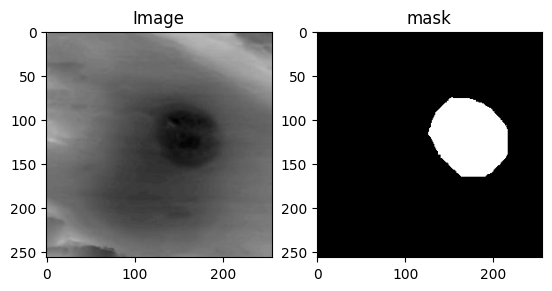

In [10]:
train_images, train_masks, val_images, val_masks, test_images, test_masks = d.load_data(depth=True)
f, ax = plt.subplots(1,2)
num = random.randint(0, len(train_images))
ax[0].imshow(train_images[num])
ax[0].set_title("Image")
ax[1].imshow(train_masks[num], cmap="gray")
ax[1].set_title("mask")

now we are going to convert the binary image to coco json 

In [6]:
from detectron2.data.datasets import register_coco_instances
d.convert_binary_to_coco()

register_coco_instances("my_dataset_train", {}, "../../data/processed_data/rgb/train/images/train.json", "../../data/processed_data/rgb/train/images/")
register_coco_instances("my_dataset_val", {}, "../../data/processed_data/rgb/val/images/val.json", "../../data/processed_data/rgb/val/images/")
register_coco_instances("my_dataset_test", {}, "../../data/processed_data/rgb/test/images/test.json", "../../data/processed_data/rgb/test/images/")

Created 507 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/rgb/train/masks
Created 76 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/rgb/val/masks
Created 282 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/rgb/test/masks
Created 507 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/depth/train/masks
Created 76 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/depth/val/masks
Created 282 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/depth/test/masks
Created 507 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/rgd/train/masks
Created 76 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/rgd/val/masks
Created 282 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/p

In [7]:
train_metadata = MetadataCatalog.get("my_dataset_train")
train_dataset_dicts = DatasetCatalog.get("my_dataset_train")

val_metadata = MetadataCatalog.get("my_dataset_val")
val_dataset_dicts = DatasetCatalog.get("my_dataset_val")

test_metadata = MetadataCatalog.get("my_dataset_test")
test_dataset_dicts = DatasetCatalog.get("my_dataset_test")

[07/02 06:39:17 d2.data.datasets.coco]: Loaded 180 images in COCO format from ../../data/processed_data/rgb/train/images/train.json
[07/02 06:39:17 d2.data.datasets.coco]: Loaded 24 images in COCO format from ../../data/processed_data/rgb/val/images/val.json
[07/02 06:39:17 d2.data.datasets.coco]: Loaded 36 images in COCO format from ../../data/processed_data/rgb/test/images/test.json


test annotations at a glance

Image file: ../../data/processed_data/rgb/val/images/val_14.jpg
Mask file: ../../data/processed_data/val/masks/Tumor/val_14.png
Failed to load mask: ../../data/processed_data/val/masks/Tumor/val_14.png


[ WARN:0@1864.808] global loadsave.cpp:268 findDecoder imread_('../../data/processed_data/val/masks/Tumor/val_14.png'): can't open/read file: check file path/integrity


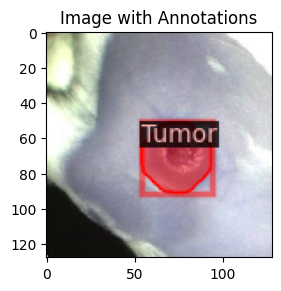

In [56]:
mask_folder = "../../data/processed_data/val/masks/Tumor"  # Update with your binary mask folder path

for d in random.sample(val_dataset_dicts, 1):
    # Load the image
    img = cv2.imread(d["file_name"])

    print(f"Image file: {d['file_name']}")
    
    # Check if the image was successfully loaded
    if img is None:
        print(f"Failed to load image: {d['file_name']}")
        continue

    # Visualize the image with annotations
    visualizer = Visualizer(img[:, :, ::-1], metadata=val_metadata, scale=0.5)
    vis = visualizer.draw_dataset_dict(d)

    # Display the annotated image
    plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
    plt.imshow(vis.get_image()[:, :, ::-1])
    plt.title("Image with Annotations")

    # Load the corresponding binary mask
    image_base_name = os.path.basename(d["file_name"]).split(".")[0]  # Get base name of the image
    mask_path = os.path.join(mask_folder, f"{image_base_name}.png")  # Assuming masks have .jpg extension

    print(f"Mask file: {mask_path}")
    
    # Load the binary mask
    mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Check if the mask was successfully loaded
    if mask_img is None:
        print(f"Failed to load mask: {mask_path}")
        continue

    # Display the binary mask
    plt.subplot(1, 2, 2)  # 1 row, 2 columns, second subplot
    plt.imshow(mask_img, cmap="gray")
    plt.title("Binary Mask")

    plt.show()  # Display the images side by side

# Testing Data functions 

### Testing create binary mask

this section is mainly for testing the create binary mask function, where the issue is that some colors from the highlighted region are being left out

In [ ]:
"""
below is a copy of the used function for testing 
currently there are two ranges, and the colors in both of those ranges are combined 
the two ranges create the mask
"""
def create_binary_masks(image_array: List[np.ndarray]) -> List[np.ndarray]:
    binary_masks = []
    
    for image in image_array:
        if image.ndim == 2:
            image_color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        elif image.shape[2] != 3:
            raise ValueError("Input image must have 3 channels (BGR format).")
        else:
            image_color = image
        
        hsv = cv2.cvtColor(image_color, cv2.COLOR_BGR2HSV)

        lower_red1 = np.array([0, 150, 50])
        upper_red1 = np.array([10, 255, 255])
        lower_red2 = np.array([170, 150, 50])
        upper_red2 = np.array([180, 255, 255])

        # Create masks for the red color
        mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
        mask2 = cv2.inRange(hsv, lower_red2, upper_red2)

        # Combine the two masks
        mask = cv2.bitwise_or(mask1, mask2)
        
        binary_masks.append(mask)
        
    return binary_masks

find an image that has a bad mask for sampling. For this case, we used image 118

image sampled: 136


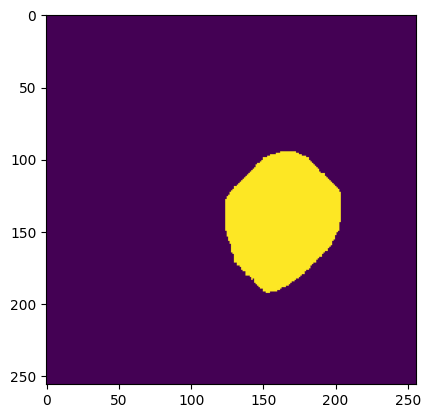

In [85]:
num = random.randint(0, len(train_masks))
print("image sampled:", num)
plt.imshow(train_masks[num])
plt.show()

Now we check that image to see

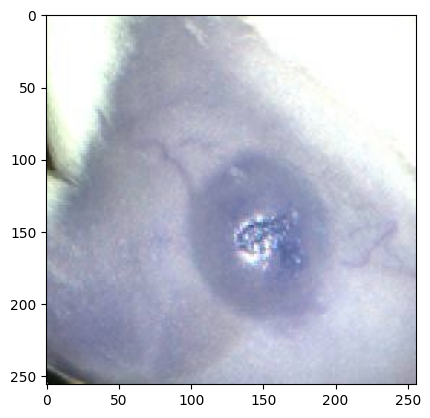

In [86]:
plt.imshow(train_images[num])

### Testing subset

In [3]:
train_arr = [13, 30, 31, 34, 37, 40, 41, 43, 44, 45, 46, 47, 49, 68, 69, 78, 79, 80, 81, 82, 88, 89, 92, 93, 94, 96, 97, 98, 99, 117, 154, 164, 168, 171, 174]
val_arr = [0, 1, 2, 3, 4, 5, 6, 7, 9]
test_arr = [8, 13, 17, 18, 22, 23, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]

In [4]:
d.create_subset(train_arr=train_arr, test_arr=test_arr, val_arr=val_arr)

Image 37 is removed
Image 171 is removed
Image 34 is removed
Image 164 is removed
Image 174 is removed
Image 30 is removed
Image 31 is removed
Image 69 is removed
Image 41 is removed
Image 82 is removed
Image 96 is removed
Image 97 is removed
Image 40 is removed
Image 68 is removed
Image 81 is removed
Image 80 is removed
Image 94 is removed
Image 43 is removed
Image 117 is removed
Image 47 is removed
Image 46 is removed
Image 44 is removed
Image 78 is removed
Image 93 is removed
Image 92 is removed
Image 79 is removed
Image 45 is removed
Image 49 is removed
Image 88 is removed
Image 89 is removed
Image 99 is removed
Image 98 is removed
Image 154 is removed
Image 168 is removed
Image 13 is removed
Image 37 is removed
Image 171 is removed
Image 34 is removed
Image 164 is removed
Image 174 is removed
Image 30 is removed
Image 31 is removed
Image 96 is removed
Image 82 is removed
Image 69 is removed
Image 41 is removed
Image 40 is removed
Image 68 is removed
Image 97 is removed
Image 81 is

### Testing binary mask

In [3]:
# get some sample data
train_images, train_masks, val_images, val_masks, test_images, test_masks = d.load_data(depth=True)

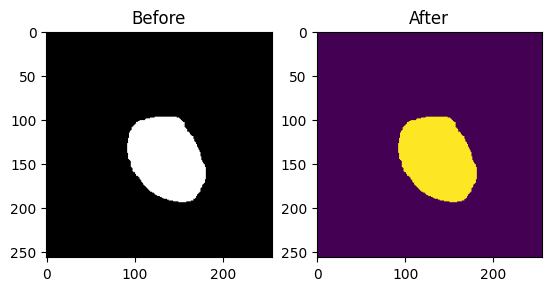

In [112]:
num = random.randint(0, len(train_masks))

_, binary = cv2.threshold(train_masks[num].copy(), 127, 255, cv2.THRESH_BINARY)
binary = cv2.cvtColor(binary, cv2.COLOR_BGR2GRAY)
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
binary = binary.astype(np.uint8)

filled = np.zeros_like(binary)
cv2.fillPoly(filled, contours, 255)

fig, ax = plt.subplots(1, 2)
ax[0].imshow(train_masks[num])
ax[0].set_title("Before")
ax[1].imshow(filled)
ax[1].set_title("After")
plt.show()


## Testing Augmnetation

In [4]:
train_metadata = MetadataCatalog.get("my_dataset_train")
train_dataset_dicts = DatasetCatalog.get("my_dataset_train")

val_metadata = MetadataCatalog.get("my_dataset_val")
val_dataset_dicts = DatasetCatalog.get("my_dataset_val")

test_metadata = MetadataCatalog.get("my_dataset_test")
test_dataset_dicts = DatasetCatalog.get("my_dataset_test")

[07/15 17:05:39 d2.data.datasets.coco]: Loaded 180 images in COCO format from /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/train/images/train.json
[07/15 17:05:39 d2.data.datasets.coco]: Loaded 24 images in COCO format from /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/val/images/val.json
[07/15 17:05:39 d2.data.datasets.coco]: Loaded 36 images in COCO format from /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/test/images/test.json


[07/15 17:07:48 d2.data.datasets.coco]: Loaded 180 images in COCO format from /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/train/images/train.json


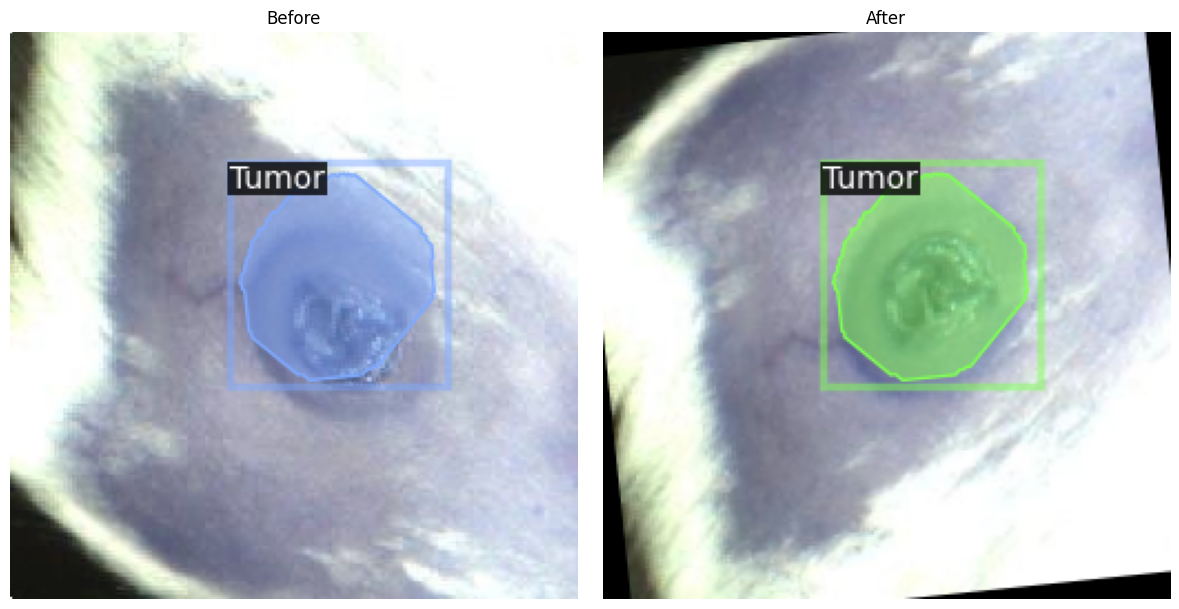

In [9]:
from detectron2.data import detection_utils as utils
from detectron2.data import transforms as T
from detectron2.utils.visualizer import Visualizer, ColorMode
import matplotlib.pyplot as plt

aug_list = T.AugmentationList([
    T.RandomFlip(prob=0, horizontal=True),    # force flip for demo
    T.RandomRotation(angle=[-30, 30], expand=False), # better to not expand?
    T.RandomFlip(prob=1.0, horizontal=False, vertical=True)
    # … any others …
])

# 2. Pick one sample
sample = DatasetCatalog.get("my_dataset_train")[42]
def apply_augs(dataset_dict):
    img = utils.read_image(dataset_dict["file_name"], format="BGR")
    annos = dataset_dict["annotations"]
    aug_input = T.StandardAugInput(img)
    transforms = aug_list(aug_input)
    img_aug = aug_input.image
    annos_aug = [
        utils.transform_instance_annotations(obj, transforms, img_aug.shape[:2])
        for obj in annos
    ]
    return img, annos, img_aug, annos_aug

before_img, before_annos, after_img, after_annos = apply_augs(sample)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, img, annos, title in zip(
    axes,
    [before_img, after_img],
    [before_annos, after_annos],
    ["Before", "After"]
):
    vis = Visualizer(img[:, :, ::-1], metadata=MetadataCatalog.get("my_dataset_train"), 
                     instance_mode=ColorMode.IMAGE_BW)
    out = vis.draw_dataset_dict({"annotations": annos})
    ax.imshow(out.get_image()[:, :, ::-1])
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

